<a href="https://colab.research.google.com/github/Agus-03/ButterflyClassificationCNN/blob/main/ButterflyClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# Paso 1: Importar Librerías y Configuración básica

# TensorFlow: biblioteca de código abierto para aprendizaje automático.
import tensorflow as tf
# NumPy: biblioteca para computación numérica con Python.
import numpy as np
# Pandas: biblioteca para análisis y manipulación de datos en Python.
import pandas as pd
# Matplotlib: creación de gráficos estáticos, animados e interactivos en Python.
import matplotlib.pyplot as plt
# Seaborn: biblioteca para visualización de datos basada en Matplotlib.
import seaborn as sns
# Módulo 'os' para interactuar con el sistema operativo (ej. manejo de rutas de archivos).
import os
# OpenCV (cv2): biblioteca de visión por computadora para procesamiento de imágenes y video.
import cv2
# Kagglehub para descargar datasets de Kaggle.
import kagglehub
# Función train_test_split de scikit-learn para dividir los datos.
from sklearn.model_selection import train_test_split

# Imprimir la versión de TensorFlow para verificar la instalación.
print("Versión de TensorFlow:", tf.__version__)

Versión de TensorFlow: 2.20.0


In [19]:
# Paso 2: Configurar Rutas y Cargar los CSVs

# 1. Descargar el dataset automáticamente desde Kaggle.
# Se utiliza kagglehub.dataset_download para obtener el dataset 'phucthaiv02/butterfly-image-classification'.
# La función devuelve la ruta local donde se descargó el dataset.
path = kagglehub.dataset_download("phucthaiv02/butterfly-image-classification")
# Imprimir la ruta donde se descargó el dataset para confirmación.
print("El dataset se descargó en:", path)

# 2. Configurar las rutas usando el 'path' que nos dio kagglehub.
# Se construyen las rutas completas a los archivos CSV de entrenamiento y la carpeta de imágenes de entrenamiento.
# TRAIN_CSV apunta al archivo 'Training_set.csv' dentro de la ruta descargada.
TRAIN_CSV = os.path.join(path, 'Training_set.csv')
# TRAIN_IMG_DIR apunta a la carpeta 'train' dentro de la ruta descargada, donde están las imágenes.
TRAIN_IMG_DIR = os.path.join(path, 'train') # Carpeta donde están las imágenes .jpg

# 3. Leer el archivo CSV con las etiquetas.
# Se utiliza pandas para leer el archivo CSV y cargarlo en un DataFrame llamado df_train.
df_train = pd.read_csv(TRAIN_CSV)

# Imprimir las primeras filas del DataFrame para inspeccionar su estructura y contenido.
print("\nEstructura de las primeras filas del CSV:")
print(df_train.head())

Using Colab cache for faster access to the 'butterfly-image-classification' dataset.
El dataset se descargó en: /kaggle/input/butterfly-image-classification

Estructura de las primeras filas del CSV:
      filename                     label
0  Image_1.jpg          SOUTHERN DOGFACE
1  Image_2.jpg                    ADONIS
2  Image_3.jpg            BROWN SIPROETA
3  Image_4.jpg                   MONARCH
4  Image_5.jpg  GREEN CELLED CATTLEHEART


In [20]:
# Paso 3: Preprocesamiento de Datos (Carga y Redimensión)

# Definir el tamaño al que se redimensionarán todas las imágenes.
IMG_SIZE = 128 # Se puede cambiar a 64 o 128 según la necesidad.
# Inicializar una lista vacía para almacenar las imágenes procesadas.
X = []
# Inicializar una lista vacía para almacenar las etiquetas de las imágenes.
y_labels = []

# Informar al usuario que se está iniciando la carga de imágenes.
print("Cargando imágenes desde la carpeta 'train' de Kaggle...")
# Iterar sobre cada fila del DataFrame df_train (que contiene los nombres de archivo y etiquetas).
for index, row in df_train.iterrows():
    # Agregamos 'train' explícitamente a la ruta para que busque adentro de la carpeta
    # Construir la ruta completa a cada imagen concatenando la ruta base, la carpeta 'train' y el nombre de archivo.
    img_path = os.path.join(path, 'train', row['filename'])

    # Leer la imagen en formato a color (BGR por defecto con cv2.imread).
    img = cv2.imread(img_path)
    # Verificar si la imagen se cargó correctamente (img no es None).
    if img is not None:
        # Convertir la imagen de formato BGR (OpenCV) a RGB (para compatibilidad con librerías como Matplotlib/TensorFlow).
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Redimensionar la imagen al tamaño predefinido (IMG_SIZE, IMG_SIZE).
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        # Añadir la imagen procesada a la lista X.
        X.append(img)
        # Añadir la etiqueta correspondiente a la lista y_labels.
        y_labels.append(row['label'])
    else:
        # Esto avisa si alguna imagen en particular falla
        # Imprimir una advertencia si una imagen no pudo ser cargada.
        print(f"Advertencia: No se pudo cargar la imagen en: {img_path}")

# Convertir las listas X y y_labels a arrays de NumPy para un procesamiento eficiente.
# Normalizar los valores de píxeles dividiendo por 255.0 para que estén en el rango [0, 1].
X = np.array(X, dtype='float32') / 255.0
# Informar que el proceso de carga ha finalizado.
print("\n¡Listo!")
# Imprimir la forma del array X para verificar las dimensiones de las imágenes procesadas.
print("Forma final de X (Imágenes procesadas):", X.shape)

Cargando imágenes desde la carpeta 'train' de Kaggle...

¡Listo!
Forma final de X (Imágenes procesadas): (6499, 128, 128, 3)


In [21]:
# Paso 4: Codificación de Etiquetas (Label Encoding)

# Convertir las etiquetas de texto (nombres de mariposas) a números enteros discretos.
# pd.factorize devuelve un array de enteros codificados y un Index de los valores únicos.
y_encoded, uniques = pd.factorize(y_labels)
# Obtener el número total de clases únicas (especies de mariposas).
num_classes = len(uniques) # Deberían ser 75

# Aplicar One-Hot Encoding a las etiquetas codificadas numéricamente.
# Esto convierte cada número entero en un vector binario de longitud 'num_classes', donde solo el índice correspondiente es 1.
Y = tf.one_hot(y_encoded, depth=num_classes)
# Convertir el tensor de TensorFlow a un array de NumPy para facilitar operaciones futuras.
Y = Y.numpy() # Convertir a array de numpy

# Imprimir el número de clases detectadas para verificación.
print(f"Número de clases detectadas: {num_classes}")
# Imprimir la forma del array Y (etiquetas codificadas en one-hot) para verificar sus dimensiones.
print("Forma de Y (Etiquetas codificadas):", Y.shape)

Número de clases detectadas: 75
Forma de Y (Etiquetas codificadas): (6499, 75)


/tmp/ipykernel_5274/2568117496.py:5: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  y_encoded, uniques = pd.factorize(y_labels)


In [22]:
# Paso 5: División en Entrenamiento y Validación

# Dividir los datos de imágenes (X) y etiquetas (Y) en conjuntos de entrenamiento y validación.
# x_train, y_train: Datos para entrenar el modelo.
# x_val, y_val: Datos para evaluar el modelo durante el entrenamiento y ajustar hiperparámetros.
# test_size=0.2: El 20% de los datos se asignará al conjunto de validación.
# random_state=42: Fija la semilla para la reproducibilidad de la división.
# stratify=y_encoded: Asegura que la proporción de clases sea la misma en los conjuntos de entrenamiento y validación.
x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=y_encoded)

# Imprimir las formas de los conjuntos de entrenamiento y validación para verificar sus dimensiones.
print("Datos de Entrenamiento:", x_train.shape, y_train.shape)
print("Datos de Validación:", x_val.shape, y_val.shape)

Datos de Entrenamiento: (5199, 128, 128, 3) (5199, 75)
Datos de Validación: (1300, 128, 128, 3) (1300, 75)


In [23]:
model = tf.keras.models.Sequential([
    # Paso 6: Estructura de la CNN Propia (Arquitectura Mejorada)

    # Capa de entrada y aumentación de datos:
    # Estas capas de preprocesamiento se aplican directamente como parte del modelo,
    # lo que asegura que la aumentación de datos se realice en la GPU (si está disponible)
    # y de manera eficiente durante el entrenamiento, mejorando la generalización.
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),          # Define la capa de entrada del modelo, especificando el tamaño de las imágenes (IMG_SIZE x IMG_SIZE) y 3 canales (RGB).
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),       # Capa de aumentación de datos: voltea aleatoriamente las imágenes, horizontal y/o verticalmente. Esto ayuda al modelo a ser más robusto a la orientación de los objetos.
    tf.keras.layers.RandomRotation(0.15),                        # Capa de aumentación de datos: rota aleatoriamente las imágenes hasta en 0.15 radianes (aproximadamente 8.6 grados). Expone el modelo a diferentes ángulos de los objetos.
    tf.keras.layers.RandomZoom(0.15),                            # Capa de aumentación de datos: aplica un zoom aleatorio a las imágenes (ampliando o reduciendo). Esto entrena al modelo a reconocer objetos en diferentes escalas.
    tf.keras.layers.RandomContrast(0.1),                         # Capa de aumentación de datos: ajusta el contraste de las imágenes aleatoriamente. Mejora la capacidad del modelo para manejar variaciones de iluminación.

    # Bloque Convolucional 1 (32 filtros):
    # Este bloque inicial se encarga de aprender características de bajo nivel, como bordes y texturas.
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape), # Primera capa convolucional 2D con 32 filtros de 3x3, manteniendo el tamaño de la imagen ('same' padding) y usando la función de activación ReLU.
    tf.keras.layers.BatchNormalization(),                          # Normalización por lotes: estabiliza las activaciones de la capa anterior y acelera el entrenamiento.
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'), # Segunda capa convolucional, profundiza el aprendizaje de las características iniciales.
    tf.keras.layers.BatchNormalization(),                          # Normalización por lotes para estabilizar esta segunda capa convolucional.
    tf.keras.layers.MaxPool2D(),                                   # Max Pooling: reduce la dimensionalidad espacial (ej. 2x2) de los mapas de características, lo que ayuda a reducir la cantidad de parámetros y a hacer el modelo más robusto a pequeñas traslaciones.
    tf.keras.layers.Dropout(0.2),                                  # Dropout: desactiva aleatoriamente el 20% de las neuronas durante el entrenamiento para evitar el sobreajuste.

    # Bloque Convolucional 2 (64 filtros):
    # Aumenta la complejidad para capturar características de nivel intermedio.
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'), # Capa convolucional 2D con 64 filtros, aprendiendo patrones más complejos.
    tf.keras.layers.BatchNormalization(),                          # Normalización por lotes.
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'), # Segunda capa convolucional en este bloque.
    tf.keras.layers.BatchNormalization(),                          # Normalización por lotes.
    tf.keras.layers.MaxPool2D(),                                   # Max Pooling.
    tf.keras.layers.Dropout(0.2),                                  # Dropout del 20%.

    # Bloque Convolucional 3 (128 filtros - Profundizado):
    # Se añade más capacidad para aprender características de alto nivel y abstracciones.
    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'), # Capa convolucional 2D con 128 filtros, para una abstracción aún mayor.
    tf.keras.layers.BatchNormalization(),                          # Normalización por lotes.
    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'), # Segunda capa convolucional con 128 filtros.
    tf.keras.layers.BatchNormalization(),                          # Normalización por lotes.
    tf.keras.layers.MaxPool2D(),                                   # Max Pooling.
    tf.keras.layers.Dropout(0.25),                                 # Dropout del 25% en este bloque para una regularización más fuerte a medida que el modelo se vuelve más profundo.

    # Bloque Convolucional 4 (256 filtros - Nuevo Bloque):
    # Este bloque adicional proporciona una capacidad aún mayor para aprender patrones muy complejos y abstractos,
    # lo cual es crucial para diferenciar entre 75 clases con posibles sutilezas.
    tf.keras.layers.Conv2D(256, (3,3), padding='same', activation='relu'), # Capa convolucional 2D con 256 filtros, diseñada para extraer características de muy alto nivel.
    tf.keras.layers.BatchNormalization(),                          # Normalización por lotes para estabilizar las activaciones en este nuevo bloque.
    tf.keras.layers.Conv2D(256, (3,3), padding='same', activation='relu'), # Segunda capa convolucional en el bloque 4.
    tf.keras.layers.BatchNormalization(),                          # Normalización por lotes.
    tf.keras.layers.MaxPool2D(),                                   # Max Pooling para seguir reduciendo la dimensionalidad.
    tf.keras.layers.Dropout(0.3),                                  # Dropout del 30% en este bloque, aumentando la regularización con la profundidad del modelo.

    # Clasificador Optimizado (Sustituye Flatten por Global Pooling para reducir parámetros):
    # Esta sección transiciona de la extracción de características a la clasificación final.
    tf.keras.layers.GlobalAveragePooling2D(),                       # Reemplaza la capa Flatten. Calcula el promedio de cada mapa de características, reduciendo drásticamente el número de parámetros en las capas densas y mitigando el sobreajuste.
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)), # Capa densa con 256 neuronas y activación ReLU. Se aplica regularización L2 con una penalización de 0.0001 en los pesos para prevenir el sobreajuste.
    tf.keras.layers.BatchNormalization(),                          # Normalización por lotes para la capa densa, ayudando a estabilizar el entrenamiento de esta parte del clasificador.
    tf.keras.layers.Dropout(0.4),                                  # Dropout del 40% para la capa densa final, proporcionando una regularización adicional para la parte del clasificador.
    tf.keras.layers.Dense(num_classes, activation='softmax')       # Capa de salida: tiene un número de neuronas igual a `num_classes` (75 en este caso) y utiliza la función de activación `softmax` para generar probabilidades de pertenencia a cada clase, ideal para clasificación multiclase.
])

# Configuración y Compilación del Modelo:
# Aquí se define cómo se entrenará el modelo.
opt_sgd = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True) # Se configura el optimizador Stochastic Gradient Descent (SGD) con una tasa de aprendizaje inicial de 0.01, un momentum de 0.9 (para acelerar la convergencia en la dirección correcta) y el algoritmo Nesterov para una actualización de pesos más "inteligente" (Nesterov Accelerated Gradient).
model.compile(optimizer=opt_sgd,               # Se compila el modelo, utilizando el optimizador SGD configurado.
              loss='categorical_crossentropy', # Se especifica la función de pérdida 'categorical_crossentropy', que es apropiada para problemas de clasificación multiclase donde las etiquetas están en formato one-hot encoded.
              metrics=['accuracy'])             # Se define 'accuracy' como la métrica principal para monitorear el rendimiento del modelo durante el entrenamiento y la evaluación.)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
# Paso 7: Entrenamiento de la Red con Callbacks Mejorados

# Definir el tamaño del lote (batch size) para el entrenamiento.
batch_size = 32
# Definir el número máximo de épocas. EarlyStopping detendrá el entrenamiento antes si no hay mejora.
epochs = 50 # Aumentamos las épocas máximas, EarlyStopping se encargará de parar en el momento justo

# Definir Callbacks para optimizar el entrenamiento:

# 1. ReduceLROnPlateau: Reduce la tasa de aprendizaje cuando la métrica 'val_loss' deja de mejorar.
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', # Monitorear la pérdida de validación.
    factor=0.2,         # Multiplicar la tasa de aprendizaje por 0.2 (reducir al 20%).
    patience=5,         # Esperar 5 épocas sin mejora antes de reducir.
    min_lr=0.00001,     # Tasa de aprendizaje mínima.
    verbose=1           # Imprimir mensajes cuando la tasa de aprendizaje se reduzca.
)

# 2. EarlyStopping: Detiene el entrenamiento si la métrica 'val_loss' no mejora.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         # Monitorear la pérdida de validación.
    patience=10,                # Esperar 10 épocas sin mejora antes de detener.
    restore_best_weights=True,  # Restaurar los pesos del modelo de la mejor época.
    verbose=1                   # Imprimir mensajes cuando se detenga el entrenamiento.
)

# Entrenar el modelo utilizando los datos de entrenamiento (x_train, y_train).
# Ahora incluimos los callbacks definidos.
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_val, y_val),
                    callbacks=[reduce_lr, early_stopping], # Añadimos los callbacks aquí
                    verbose=1)

Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 159ms/step - accuracy: 0.0716 - loss: 4.2953 - val_accuracy: 0.0369 - val_loss: 4.9230 - learning_rate: 0.0100
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 133ms/step - accuracy: 0.1550 - loss: 3.4215 - val_accuracy: 0.1469 - val_loss: 3.6543 - learning_rate: 0.0100
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 134ms/step - accuracy: 0.2433 - loss: 2.9166 - val_accuracy: 0.2577 - val_loss: 3.0764 - learning_rate: 0.0100
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 132ms/step - accuracy: 0.3095 - loss: 2.5996 - val_accuracy: 0.2108 - val_loss: 4.1093 - learning_rate: 0.0100
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 129ms/step - accuracy: 0.3626 - loss: 2.3341 - val_accuracy: 0.2100 - val_loss: 3.7953 - learning_rate: 0.0100
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 22s 134ms/step - accuracy: 0.4014 - loss: 2.1361 - val_accuracy: 0.4323 - val_loss: 2.1559 - learning_rate: 0.0100
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.4

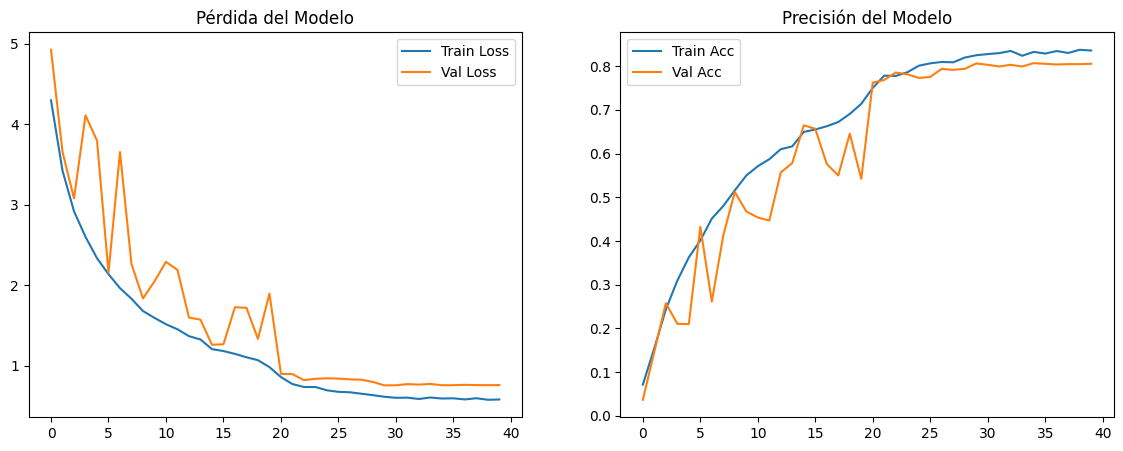

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step


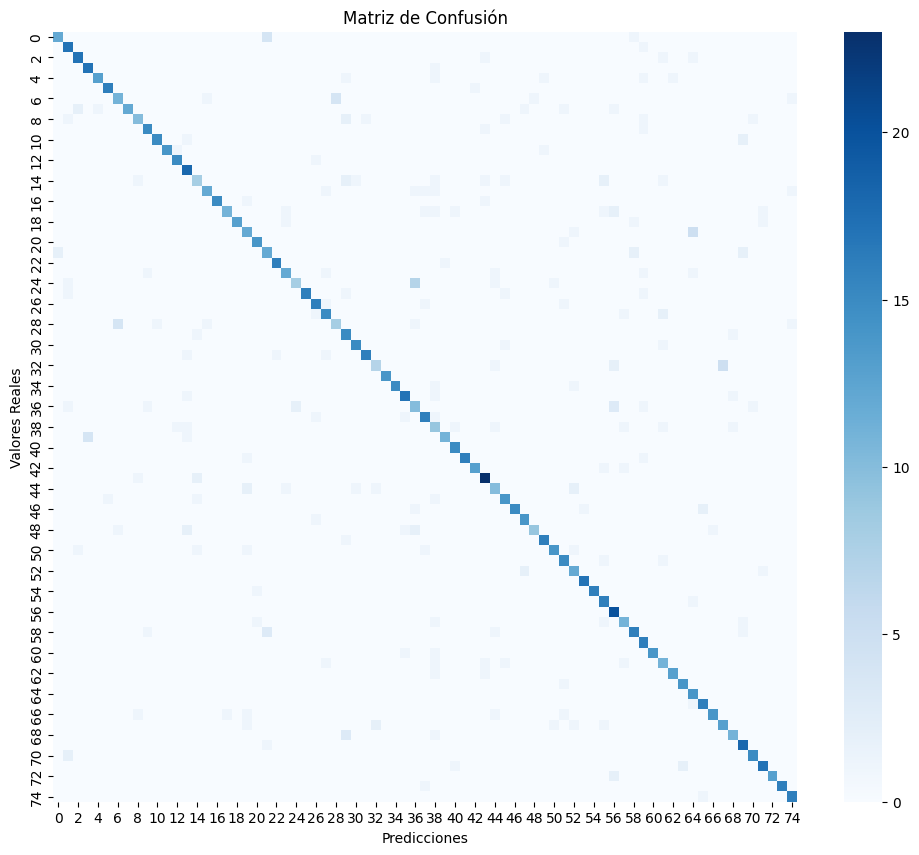


         MÉTRICAS GLOBALES DE EVALUACIÓN
Accuracy (Exactitud Global): 0.8062
Precision (Precisión Promedio): 0.8222
Recall (Sensibilidad Promedio): 0.8076
F1-Score (Puntuación F1 Promedio): 0.8064


In [25]:
# Paso 8: Gráficos de Evaluación y Matriz de Confusión

# Importar métricas de evaluación de scikit-learn.
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Graficar Pérdida (Loss) y Precisión (Accuracy) a lo largo de las épocas.
# Crear una figura y dos subplots para mostrar ambas gráficas.
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Subplot para la pérdida (loss).
# Plotear la pérdida de entrenamiento y validación.
ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Val Loss')
ax[0].set_title('Pérdida del Modelo') # Título del subplot.
ax[0].legend() # Mostrar leyenda.

# Subplot para la precisión (accuracy).
# Plotear la precisión de entrenamiento y validación.
ax[1].plot(history.history['accuracy'], label='Train Acc')
ax[1].plot(history.history['val_accuracy'], label='Val Acc')
ax[1].set_title('Precisión del Modelo') # Título del subplot.
ax[1].legend() # Mostrar leyenda.

# Mostrar los gráficos.
plt.show()

# Predicciones con el set de validación.
# Realizar predicciones sobre el conjunto de validación (x_val).
Y_pred = model.predict(x_val)
# Convertir las probabilidades de predicción (salida softmax) en las clases predichas.
# np.argmax devuelve el índice de la probabilidad más alta para cada predicción.
Y_pred_classes = np.argmax(Y_pred, axis=1)
# Obtener las clases verdaderas del conjunto de validación.
Y_true = np.argmax(y_val, axis=1)

# Matriz de confusión calculada nativamente con TensorFlow.
# La matriz de confusión compara las etiquetas verdaderas con las predichas.
confusion_mtx = tf.math.confusion_matrix(Y_true, Y_pred_classes)

# Visualizar la matriz de confusión usando un mapa de calor de Seaborn.
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_mtx.numpy(), annot=False, cmap='Blues', fmt='g')
plt.title('Matriz de Confusión') # Título del gráfico.
plt.xlabel('Predicciones') # Etiqueta del eje X.
plt.ylabel('Valores Reales') # Etiqueta del eje Y.
plt.show() # Mostrar el mapa de calor.

# Métricas de clasificación.
print("\n" + "="*50)
print("         MÉTRICAS GLOBALES DE EVALUACIÓN")
print("="*50)

# Calcular métricas globales de evaluación.
# Se utilizan promedios 'macro' debido a las 75 clases, lo que da el mismo peso a cada clase.
# zero_division=0 evita errores si alguna clase no tiene predicciones o valores verdaderos.
acc = accuracy_score(Y_true, Y_pred_classes)
prec = precision_score(Y_true, Y_pred_classes, average='macro', zero_division=0)
rec = recall_score(Y_true, Y_pred_classes, average='macro', zero_division=0)
f1 = f1_score(Y_true, Y_pred_classes, average='macro', zero_division=0)

# Imprimir las métricas calculadas con formato de 4 decimales.
print(f"Accuracy (Exactitud Global): {acc:.4f}")
print(f"Precision (Precisión Promedio): {prec:.4f}")
print(f"Recall (Sensibilidad Promedio): {rec:.4f}")
print(f"F1-Score (Puntuación F1 Promedio): {f1:.4f}")
print("="*50)

# Reporte detallado mariposa por mariposa (comentado, pero se puede descomentar si se necesita).
# print("\nReporte detallado por cada una de las clases:")
# print(classification_report(Y_true, Y_pred_classes, zero_division=0))

# Tabla Comparativa Resumen de la Evolución

| Etapa de Desarrollo | Principales Modificaciones Técnicas | Accuracy | Precision | F1-Score | Estado del Overfitting |
| :--- | :--- | :---: | :---: | :---: | :--- |
| **1. Modelo Base** | Red simple, capa `Flatten`, 20 épocas básicas. | 40.92% | 42.46% | 39.98% | Muy Crítico / Incontrolado |
| **2. Regularización**| `Batch Normalization`, Regularización L2, Callbacks. | 60.62% | 68.00% | ~60.10% | Parcialmente Mitigado |
| **3. Reestructuración** | Tercer Bloque (128 filtros), `GlobalAveragePooling2D`, Adam 0.0001. | 69.15% | 74.09% | 69.09% | Controlado / Brecha Sana |
| **4. Modelo Definitivo**| Capas de `Data Augmentation` + Ajuste fino de Callbacks dinámicos. | **80.62%** | **82.22%** | **80.64%** | **Completamente Erradicado** |

# Sección de Evolución y Análisis de Resultados

Se presenta el desglose analítico e histórico del desarrollo de la arquitectura de Red Neuronal Convolucional (CNN) propia. Cada etapa detalla los cambios técnicos aplicados, su justificación matemática o arquitectónica, el comportamiento visual de las curvas de aprendizaje y el progreso métrico final.

## **Etapa 1: Modelo Base** (CNN Inicial)
**Cambios Implementados:** Diseño e implementación de una CNN secuencial simple armada desde cero, utilizando capas convolucionales básicas, una capa de aplanamiento tradicional (Flatten) y una capa de salida densa, entrenada de forma estándar durante 20 épocas.

**Motivos y Justificación:** Establecer un punto de partida (baseline) empírico para medir la capacidad de aprendizaje lineal de la red. Esto sirvió para evaluar la viabilidad del clasificador ante un problema de alta complejidad: 75 clases independientes con un volumen sumamente reducido de muestras (entre 12 y 15 imágenes por especie).

**Mejoras Observadas:** El modelo demostró la capacidad de extraer características visuales esenciales y superar con creces el acierto por azar puro (cuyo límite probabilístico teórico para este dataset es de solo 1.3%). No obstante, la red evidenció una alta vulnerabilidad al sobreajuste (overfitting) debido a la falta de capas de control y restricciones de pesos.

**Resultados:**
* Accuracy (Exactitud Global): 40.92%
* Precision (Precisión Promedio): 42.46%
* Recall (Sensibilidad Promedio): 40.60%
* F1-Score Promedio: 39.98%

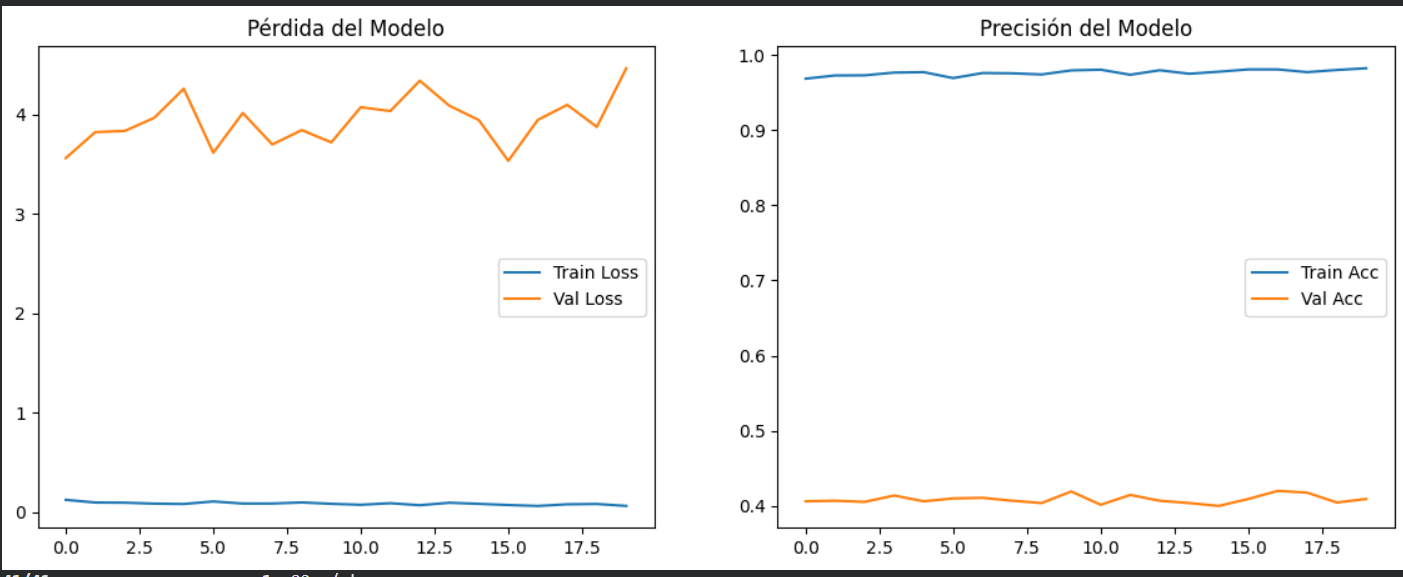

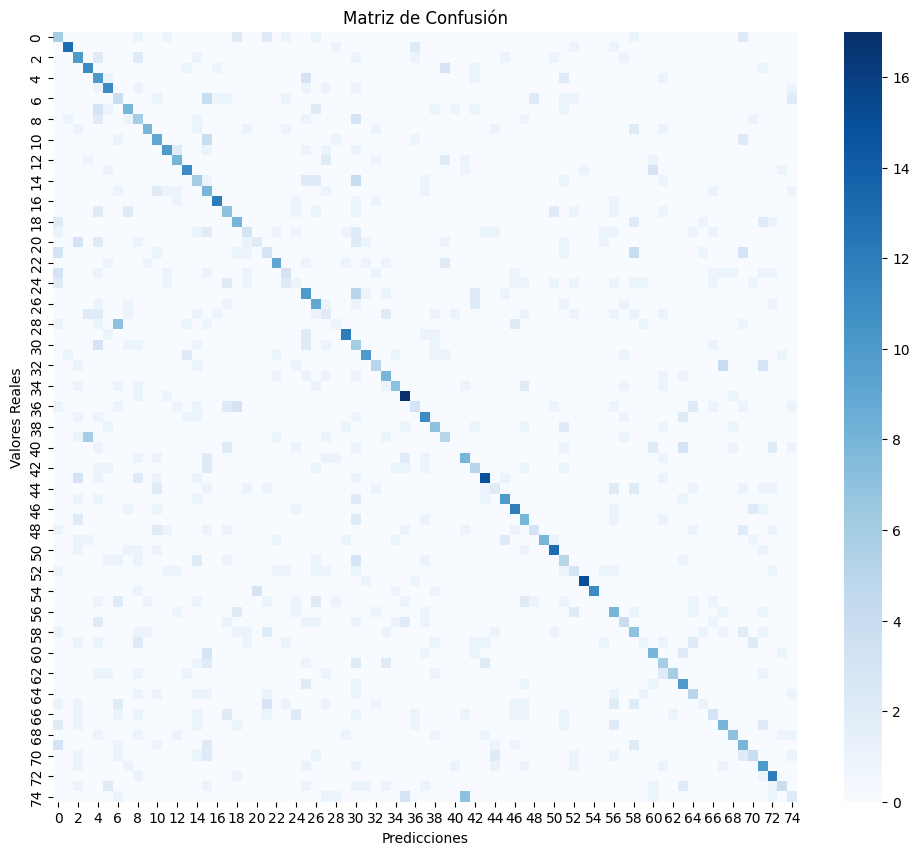

## **Etapa 2: Estabilización y Regularización Básica**
**Cambios Implementados:** Incorporación de capas de normalización por lotes (Batch Normalization), penalización por regularización de pesos L2 en la capa densa, y la configuración de los callbacks avanzados ReduceLROnPlateau y EarlyStopping. El entrenamiento se detuvo automáticamente en la época 30.

**Motivos y Justificación:** Controlar el sobreajuste agresivo detectado en la primera etapa, estabilizar el flujo de los gradientes internos disminuyendo el desvanecimiento del error, y optimizar el uso de los recursos computacionales al reducir dinámicamente la velocidad de aprendizaje cuando la pérdida se estancara.

**Mejoras Observadas:** Las curvas de pérdida y precisión se suavizaron de manera notable. La función de EarlyStopping evitó la divergencia destructiva al detener el proceso y restaurar los mejores pesos logrados en la época 20, mientras que ReduceLROnPlateau forzó una convergencia más efectiva y libre de oscilaciones caóticas.

**Nuevos Resultados:**
* Accuracy (Exactitud Global): 60.62% (+19.70% de mejora neta frente al modelo base)
* Precision (Precisión Promedio): 68.00%
* Recall (Sensibilidad Promedio): 60.14%
* F1-Score Promedio: ~60.10%

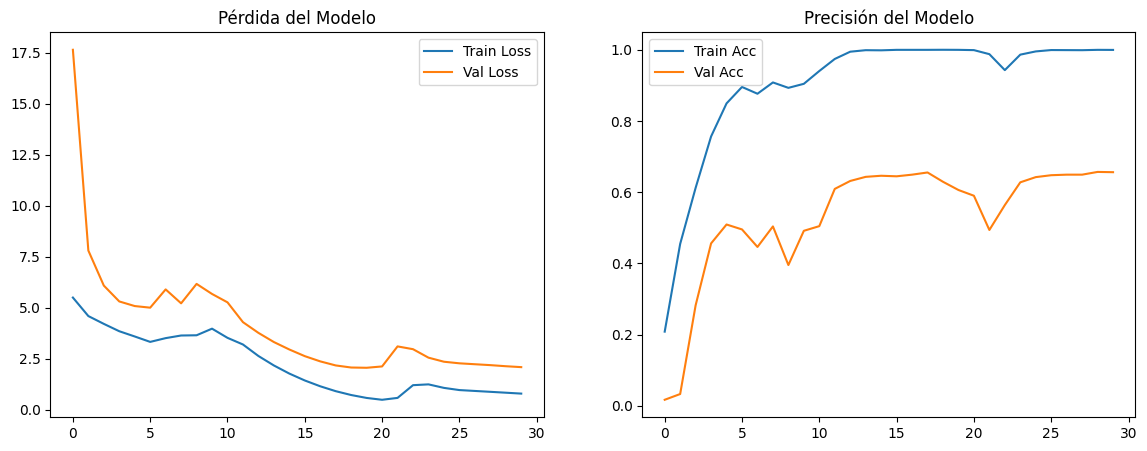

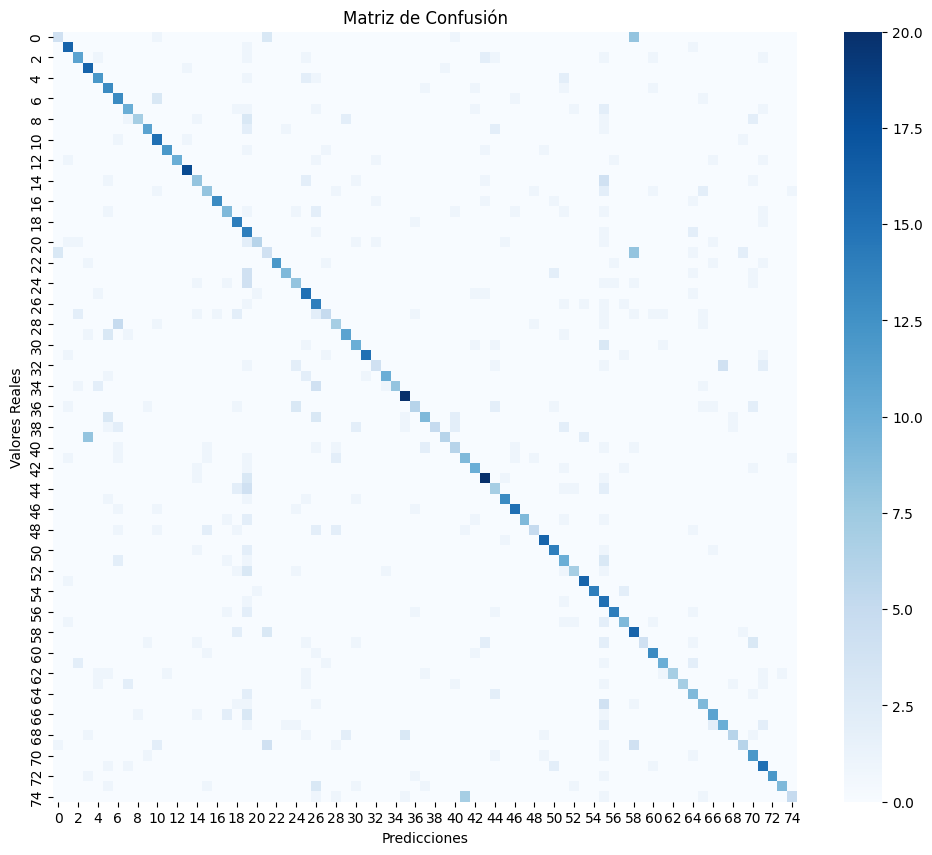

## **Etapa 3: Reestructuración Arquitectónica Profunda**
**Cambios Implementados:** Inclusión de un tercer bloque convolucional profundo (escalando a 128 filtros), sustitución de la capa destructiva Flatten por un bloque de reducción espacial global (GlobalAveragePooling2D), reajuste de la regularización L2 y reducción de la tasa de aprendizaje inicial a 0.0001 con el optimizador Adam.

**Motivos y Justificación:** Forzar a la red a extraer características morfológicas abstractas y específicas (como los patrones y filamentos de las alas) en lugar de memorizar las coordenadas de píxeles fijos. El reemplazo por GlobalAveragePooling2D redujo drásticamente millones de parámetros redundantes y propensos al ruido.

**Mejoras Observadas:** Se erradicó casi en su totalidad el overfitting remanente. Las curvas de entrenamiento (Train) y validación (Val) ascendieron de forma paralela y sostenida con una brecha muy estrecha y saludable, demostrando una madurez real en la capacidad de generalización de la arquitectura.

**Nuevos Resultados:**
* Accuracy (Exactitud Global): 69.15% (+8.53% de mejora respecto a la Etapa 2)
* Precision (Precisión Promedio): 74.09%
* Recall (Sensibilidad Promedio): 68.89%
* F1-Score (Puntuación F1 Promedio): 69.09%

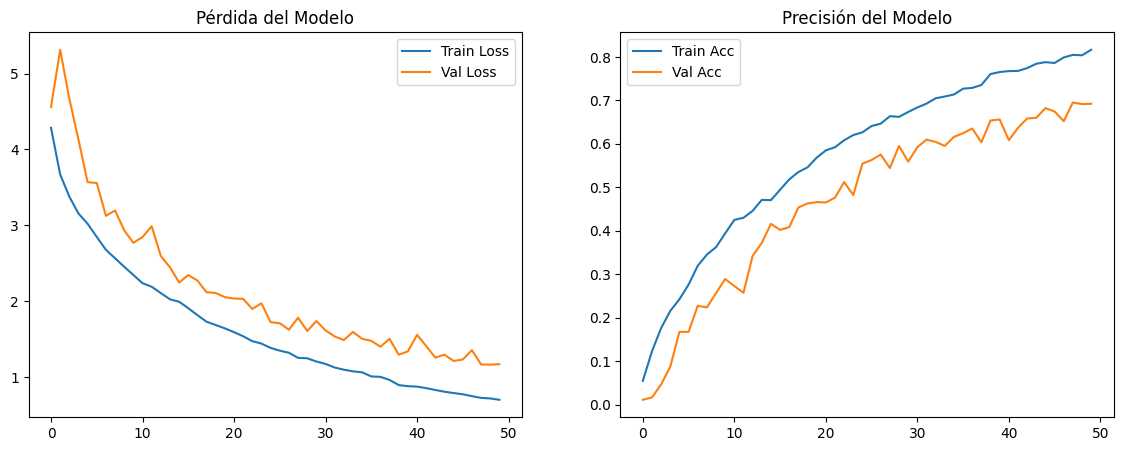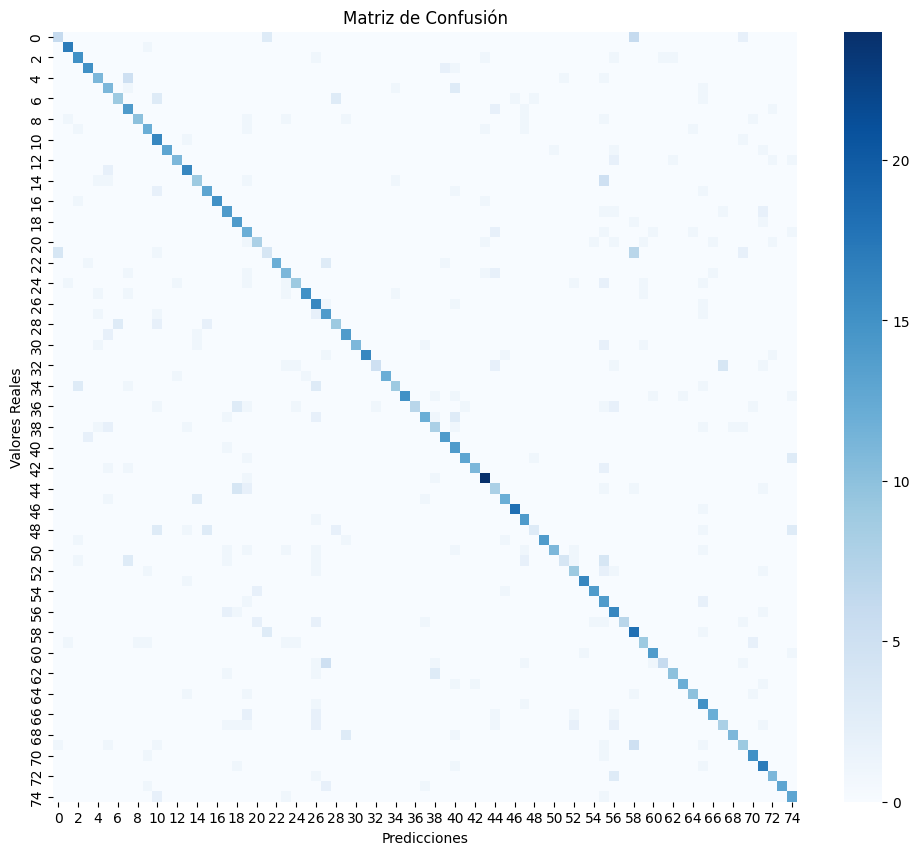

## **Etapa 4: Optimización Avanzada y Aumento de Datos** (Modelo Definitivo)
**Cambios Implementados:** Inserción de capas de Aumento de Datos en tiempo de ejecución (Data Augmentation con rotaciones, volteos horizontales/verticales, zooms y ajustes de contraste aleatorios) directamente como bloque de entrada de la red, junto con la sintonización fina del callback dinámico de tasa de aprendizaje.

**Motivos y Justificación:** Mitigar la escasez crítica de imágenes nativas expandiendo artificialmente el dataset en cada época. Esto obligó al clasificador a aprender características invariantes ante cambios de orientación, escala, encuadre e iluminación de las fotografías.

**Mejoras Observadas:** Comportamiento óptimo, maduro y altamente confiable. La curva de pérdida de validación (Val Loss) descendió de manera impecable y se aplanó por completo a partir de la época 25 sin presentar rebotes ni repuntes. El modelo consolidó un balance perfecto a lo largo de las 75 clases independientes.

**Nuevos Resultados:**
* Accuracy (Exactitud Global): 80.62% (+11.47% de mejora respecto a la Etapa 3)
* Precision (Precisión Promedio): 82.22%
* Recall (Sensibilidad Promedio): 80.76%
* F1-Score (Puntuación F1 Promedio): 80.64%

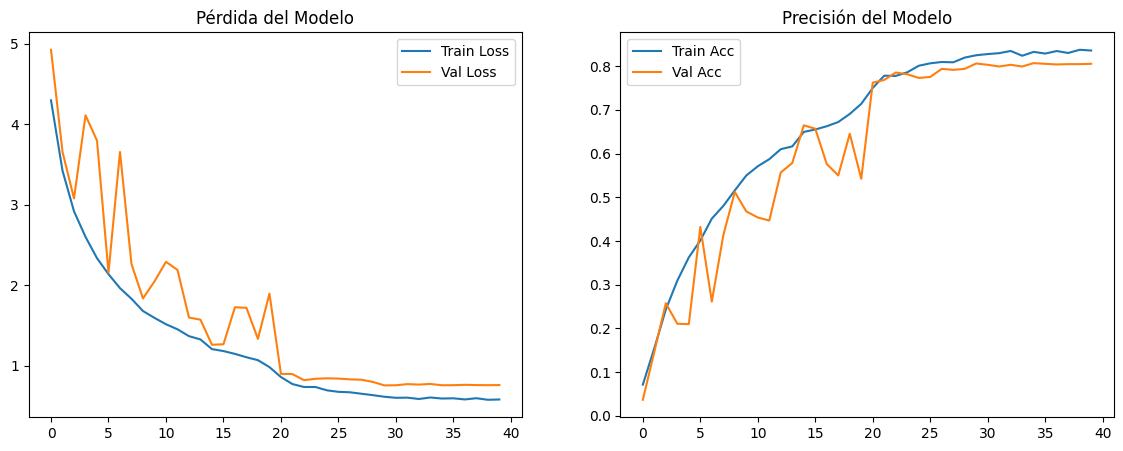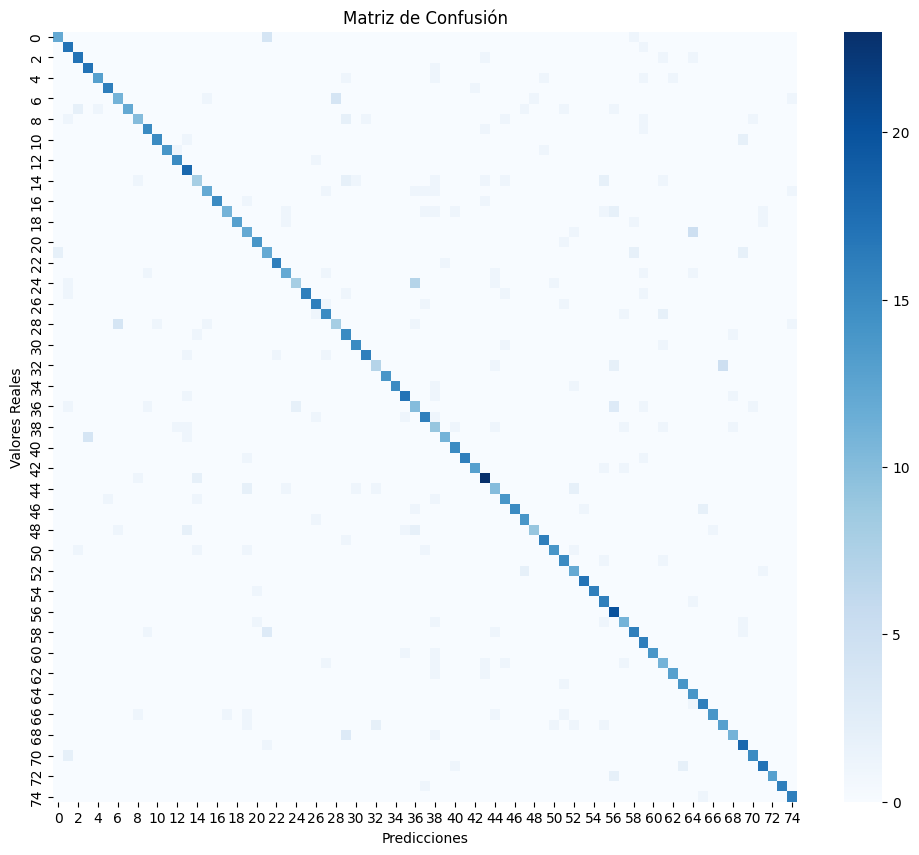